In [1]:
import pandas as pd
import gzip

from mybookrec import DATA_DIR

# Load in Data

In [ ]:
my_books_df = pd.read_csv(DATA_DIR / "raw" / "goodreads_library_export.csv")
my_books_df.head(5)

,Book Id,Title,Author,Author l-f,Additional Authors,ISBN,ISBN13,My Rating,Average Rating,Publisher,...,Date Read,Date Added,Bookshelves,Bookshelves with positions,Exclusive Shelf,My Review,Spoiler,Private Notes,Read Count,Owned Copies
0,12697427,One Flew Over the Cuckoo's Nest,Ken Kesey,"Kesey, Ken",Robert Faggen,"=""067002323X""","=""9780670023233""",0,4.20,Viking,...,NaN,2025/08/20,currently-reading,currently-reading (#1),currently-reading,NaN,NaN,NaN,1,0
1,40864002,"A Psalm for the Wild-Built (Monk & Robot, #1)",Becky Chambers,"Chambers, Becky",NaN,"=""""","=""""",4,4.21,Tordotcom,...,2026/03/12,2026/02/06,NaN,NaN,read,NaN,NaN,NaN,1,0
2,243331918,The Anthony Bourdain Reader,Anthony Bourdain,"Bourdain, Anthony",Kimberly Witherspoon,"=""1526696568""","=""9781526696564""",3,4.11,Bloomsbury Publishing PLC,...,2026/02/27,2026/01/25,NaN,NaN,read,NaN,NaN,NaN,1,0
3,201033505,She's Always Hungry,Eliza Clark,"Clark, Eliza",NaN,"=""0063393263""","=""9780063393264""",0,3.73,Harper Perennial,...,NaN,2026/01/27,to-read,to-read (#30),to-read,NaN,NaN,NaN,0,0
4,207851815,The Proof of My Innocence,Jonathan Coe,"Coe, Jonathan",NaN,"=""1405962429""","=""9781405962421""",0,3.74,Penguin,...,NaN,2026/01/27,to-read,to-read (#29),to-read,NaN,NaN,NaN,0,0


In [ ]:
book_map = pd.read_csv(DATA_DIR / "raw" / "book_id_map.csv")
book_map.head(10)

,book_id_csv,book_id
0,0,34684622
1,1,34536488
2,2,34017076
3,3,71730
4,4,30422361
5,5,33503613
6,6,33517540
7,7,34467031
8,8,6383669
9,9,486625


In [2]:
# Load interactions file
with gzip.open(DATA_DIR / "raw" / "goodreads_interactions_dedup.json.gz", "rt") as f:
    interactions_df = pd.read_json(f, lines=True, nrows=100000)
interactions_df.head(5)

,user_id,book_id,review_id,is_read,rating,review_text_incomplete,date_added,date_updated,read_at,started_at
0,8842281e1d1347389f2ab93d60773d4d,34684622,a53868823f065a0e20fd4ae98b820674,False,0,,Tue Oct 17 09:40:11 -0700 2017,Tue Oct 17 09:40:12 -0700 2017,,
1,8842281e1d1347389f2ab93d60773d4d,34536488,9f08c5f991f87f3b7ae4ce779c2aac10,False,0,,Fri Oct 13 07:19:50 -0700 2017,Fri Oct 13 07:19:50 -0700 2017,,
2,8842281e1d1347389f2ab93d60773d4d,34017076,14da595c5b0c38b1247888f62f74a772,False,0,,Fri Oct 06 09:32:42 -0700 2017,Fri Oct 06 09:32:43 -0700 2017,,
3,8842281e1d1347389f2ab93d60773d4d,71730,bd1a29916eb3ea1d0d45d4f7395920c5,False,0,,Tue Oct 03 23:31:03 -0700 2017,Tue Oct 03 23:39:42 -0700 2017,,
4,8842281e1d1347389f2ab93d60773d4d,30422361,d2edf29508fd36808bf30b37043acda4,False,0,,Tue Oct 03 15:05:28 -0700 2017,Tue Oct 03 15:05:29 -0700 2017,,


In [ ]:
with gzip.open(DATA_DIR / "raw" / "goodreads_books.json.gz", "rt") as file:
    books_df = pd.read_json(file, lines=True, nrows=100000)
books_df.head(5)

,isbn,text_reviews_count,series,country_code,language_code,popular_shelves,asin,is_ebook,average_rating,kindle_asin,...,publication_month,edition_information,publication_year,url,image_url,book_id,ratings_count,work_id,title,title_without_series
0,0312853122,1,[],US,,"[{'count': '3', 'name': 'to-read'}, {'count': ...",,false,4.00,,...,9,,1984,https://www.goodreads.com/book/show/5333265-w-...,https://images.gr-assets.com/books/1310220028m...,5333265,3,5400751,W.C. Fields: A Life on Film,W.C. Fields: A Life on Film
1,0743509986,6,[],US,,"[{'count': '2634', 'name': 'to-read'}, {'count...",,false,3.23,B000FC0PBC,...,10,Abridged,2001,https://www.goodreads.com/book/show/1333909.Go...,https://s.gr-assets.com/assets/nophoto/book/11...,1333909,10,1323437,Good Harbor,Good Harbor
2,,7,[189911],US,eng,"[{'count': '58', 'name': 'to-read'}, {'count':...",B00071IKUY,false,4.03,,...,,Book Club Edition,1987,https://www.goodreads.com/book/show/7327624-th...,https://images.gr-assets.com/books/1304100136m...,7327624,140,8948723,"The Unschooled Wizard (Sun Wolf and Starhawk, ...","The Unschooled Wizard (Sun Wolf and Starhawk, ..."
3,0743294297,3282,[],US,eng,"[{'count': '7615', 'name': 'to-read'}, {'count...",,false,3.49,B002ENBLOK,...,7,,2009,https://www.goodreads.com/book/show/6066819-be...,https://s.gr-assets.com/assets/nophoto/book/11...,6066819,51184,6243154,Best Friends Forever,Best Friends Forever
4,0850308712,5,[],US,,"[{'count': '32', 'name': 'to-read'}, {'count':...",,false,3.40,,...,,,,https://www.goodreads.com/book/show/287140.Run...,https://images.gr-assets.com/books/1413219371m...,287140,15,278577,Runic Astrology: Starcraft and Timekeeping in ...,Runic Astrology: Starcraft and Timekeeping in ...


In [ ]:
with gzip.open(DATA_DIR / "raw" / "goodreads_book_genres_initial.json.gz", "rt") as file:
    book_genres_df = pd.read_json(file, lines=True, nrows=100000)
book_genres_df.head(10)

,book_id,genres
0,5333265,"{'history, historical fiction, biography': 1}"
1,1333909,"{'fiction': 219, 'history, historical fiction,..."
2,7327624,"{'fantasy, paranormal': 31, 'fiction': 8, 'mys..."
3,6066819,"{'fiction': 555, 'romance': 23, 'mystery, thri..."
4,287140,{'non-fiction': 3}
5,287141,"{'history, historical fiction, biography': 9, ..."
6,378460,{'fiction': 2}
7,6066812,"{'fantasy, paranormal': 32, 'young-adult': 8, ..."
8,34883016,{'romance': 3}
9,287149,"{'non-fiction': 24, 'history, historical ficti..."


## Exploration of Books Dataframe

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
books_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 29 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   isbn                  100000 non-null  str   
 1   text_reviews_count    100000 non-null  str   
 2   series                100000 non-null  object
 3   country_code          100000 non-null  str   
 4   language_code         100000 non-null  str   
 5   popular_shelves       100000 non-null  object
 6   asin                  100000 non-null  str   
 7   is_ebook              100000 non-null  str   
 8   average_rating        100000 non-null  str   
 9   kindle_asin           100000 non-null  str   
 10  similar_books         100000 non-null  object
 11  description           100000 non-null  str   
 12  format                100000 non-null  str   
 13  link                  100000 non-null  str   
 14  authors               100000 non-null  object
 15  publisher             100000 

In [ ]:
books_df.columns

Index(['isbn', 'text_reviews_count', 'series', 'country_code', 'language_code',
       'popular_shelves', 'asin', 'is_ebook', 'average_rating', 'kindle_asin',
       'similar_books', 'description', 'format', 'link', 'authors',
       'publisher', 'num_pages', 'publication_day', 'isbn13',
       'publication_month', 'edition_information', 'publication_year', 'url',
       'image_url', 'book_id', 'ratings_count', 'work_id', 'title',
       'title_without_series'],
      dtype='str')

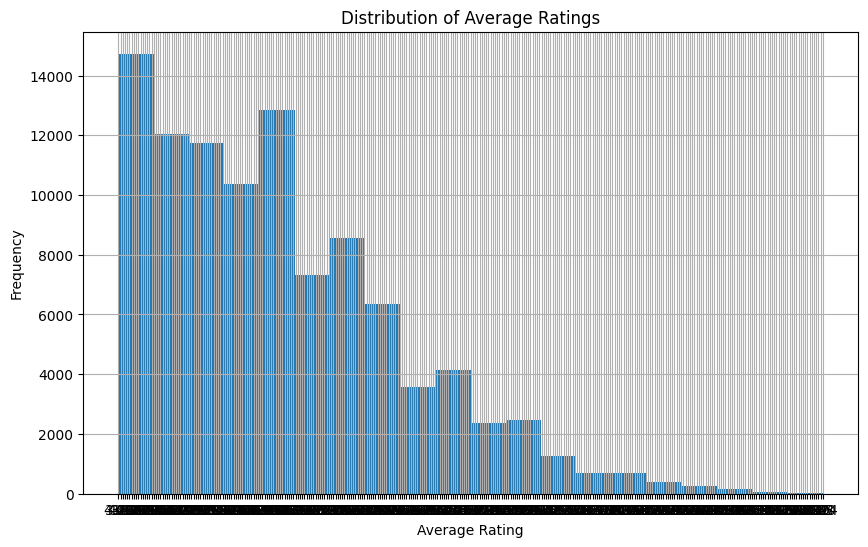

In [ ]:
# Distribution of ratings
plt.figure(figsize=(10, 6))
books_df["average_rating"].hist(bins=20)
plt.title("Distribution of Average Ratings")
plt.xlabel("Average Rating")
plt.ylabel("Frequency")
plt.show()

In [ ]:
books_df["similar_books"] # List of comma-separated book IDs that are similar to this book, based on Goodreads' algorithm.

0                                                       []
1        [8709549, 17074050, 28937, 158816, 228563, 112...
2        [19997, 828466, 1569323, 425389, 1176674, 2627...
3        [6604176, 6054190, 2285777, 82641, 7569453, 70...
4                                                       []
                               ...                        
99995                                                   []
99996    [16682136, 6364098, 6328857, 26791235, 1144239...
99997    [27280342, 22886631, 21893683, 27242745, 26074...
99998                                                   []
99999    [8581015, 9673072, 79381, 7755381, 8546464, 12...
Name: similar_books, Length: 100000, dtype: object

In [ ]:
books_df["publisher"]

0            St. Martin's Press
1        Simon & Schuster Audio
2        Nelson Doubleday, Inc.
3                   Atria Books
4                              
                  ...          
99995                          
99996                          
99997                 Tor Books
99998                          
99999                          
Name: publisher, Length: 100000, dtype: str

In [ ]:
books_df["is_ebook"]

0        false
1        false
2        false
3        false
4        false
         ...  
99995    false
99996     true
99997     true
99998     true
99999    false
Name: is_ebook, Length: 100000, dtype: str

In [ ]:
books_df["num_pages"]

0        256
1           
2        600
3        368
4           
        ... 
99995    350
99996       
99997     33
99998       
99999    358
Name: num_pages, Length: 100000, dtype: str

In [ ]:
books_df["popular_shelves"][2] # Inspect list[json] by inspecting first row

[{'count': '58', 'name': 'to-read'},
 {'count': '15', 'name': 'fantasy'},
 {'count': '6', 'name': 'fiction'},
 {'count': '5', 'name': 'owned'},
 {'count': '3', 'name': 'hardcover'},
 {'count': '2', 'name': 'shelfari-favorites'},
 {'count': '2', 'name': 'series'},
 {'count': '1', 'name': 'might-read'},
 {'count': '1', 'name': 'dnf-d'},
 {'count': '1', 'name': 'hambly-barbara'},
 {'count': '1', 'name': 'strong-females'},
 {'count': '1', 'name': 'first-in-series'},
 {'count': '1', 'name': 'fantasy-sword-sorcery'},
 {'count': '1', 'name': 'no-thanks-series-collections-boxes'},
 {'count': '1', 'name': 'fantasy-all'},
 {'count': '1', 'name': 'entertaining-but-limited'},
 {'count': '1', 'name': 'kate-own'},
 {'count': '1', 'name': 'fantasy-epic'},
 {'count': '1', 'name': 'e-book'},
 {'count': '1', 'name': 'compliation'},
 {'count': '1', 'name': 'my-books'},
 {'count': '1', 'name': 'books-i-own-but-have-not-read'},
 {'count': '1', 'name': 'everything-owned'},
 {'count': '1', 'name': 'books-to-

## EDA on Interactions DataFrame

In [3]:
interactions_df.head(5)

,user_id,book_id,review_id,is_read,rating,review_text_incomplete,date_added,date_updated,read_at,started_at
0,8842281e1d1347389f2ab93d60773d4d,34684622,a53868823f065a0e20fd4ae98b820674,False,0,,Tue Oct 17 09:40:11 -0700 2017,Tue Oct 17 09:40:12 -0700 2017,,
1,8842281e1d1347389f2ab93d60773d4d,34536488,9f08c5f991f87f3b7ae4ce779c2aac10,False,0,,Fri Oct 13 07:19:50 -0700 2017,Fri Oct 13 07:19:50 -0700 2017,,
2,8842281e1d1347389f2ab93d60773d4d,34017076,14da595c5b0c38b1247888f62f74a772,False,0,,Fri Oct 06 09:32:42 -0700 2017,Fri Oct 06 09:32:43 -0700 2017,,
3,8842281e1d1347389f2ab93d60773d4d,71730,bd1a29916eb3ea1d0d45d4f7395920c5,False,0,,Tue Oct 03 23:31:03 -0700 2017,Tue Oct 03 23:39:42 -0700 2017,,
4,8842281e1d1347389f2ab93d60773d4d,30422361,d2edf29508fd36808bf30b37043acda4,False,0,,Tue Oct 03 15:05:28 -0700 2017,Tue Oct 03 15:05:29 -0700 2017,,


In [4]:
interactions_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   user_id                 100000 non-null  str  
 1   book_id                 100000 non-null  int64
 2   review_id               100000 non-null  str  
 3   is_read                 100000 non-null  bool 
 4   rating                  100000 non-null  int64
 5   review_text_incomplete  100000 non-null  str  
 6   date_added              100000 non-null  str  
 7   date_updated            100000 non-null  str  
 8   read_at                 100000 non-null  str  
 9   started_at              100000 non-null  str  
dtypes: bool(1), int64(2), str(7)
memory usage: 7.0 MB


In [5]:
interactions_df.columns

Index(['user_id', 'book_id', 'review_id', 'is_read', 'rating',
       'review_text_incomplete', 'date_added', 'date_updated', 'read_at',
       'started_at'],
      dtype='str')

In [ ]:
# Test date parsing from string to datetime
import polars as pl
date_str = pl.Series(["Tue Oct 17 09:40:11 -0700 2017"])
date_str.str.replace_all(r"\s+", " ").str.to_datetime("%a %b %d %H:%M:%S %z %Y") # Replace multiple spaces with a single space before parsing


""
"datetime[μs, UTC]"
2017-10-17 16:40:11 UTC


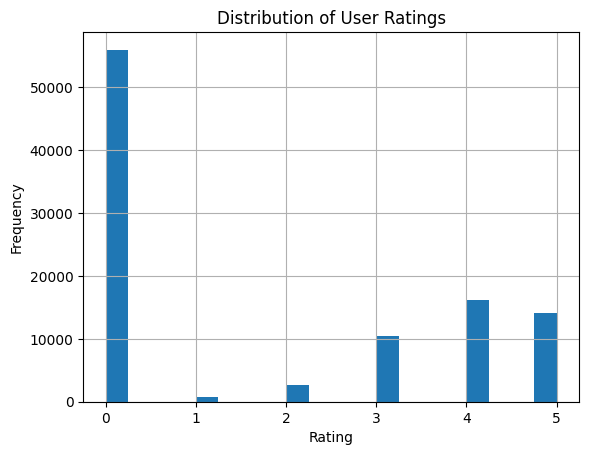

In [ ]:
# Distribution of user ratings - how many ratings of each value (1-5) are there?
interactions_df["rating"].hist(bins=20)
plt.title("Distribution of User Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

# Most common rating value is 0, which indicates an interaction without an explicit rating (e.g., a user added the book to their shelf but didn't rate it). This is common in implicit feedback datasets.


In [ ]:
interactions_df["is_read"].value_counts()

is_read
False    53124
True     46876
Name: count, dtype: int64

In [ ]:
# Number of unique users and books in the interactions dataset
num_users = interactions_df["user_id"].nunique()
num_books = interactions_df["book_id"].nunique()
print(f"Number of unique users: {num_users}")
print(f"Number of unique books: {num_books}")

Number of unique users: 228
Number of unique books: 59157


In [ ]:
# How many books has each user interacted with on average?
avg_books_per_user = interactions_df.groupby("user_id")["book_id"].nunique().mean()
print(f"Average number of books interacted with per user: {avg_books_per_user:.2f}")

Average number of books interacted with per user: 438.60


In [ ]:
avg_user_interactions = interactions_df.groupby("user_id").size().mean()
print(f"Average number of interactions per user: {avg_user_interactions:.2f}")

Average number of interactions per user: 438.60


## My Books EDA

In [ ]:
my_books_df.head(5)

,Book Id,Title,Author,Author l-f,Additional Authors,ISBN,ISBN13,My Rating,Average Rating,Publisher,...,Date Read,Date Added,Bookshelves,Bookshelves with positions,Exclusive Shelf,My Review,Spoiler,Private Notes,Read Count,Owned Copies
0,12697427,One Flew Over the Cuckoo's Nest,Ken Kesey,"Kesey, Ken",Robert Faggen,"=""067002323X""","=""9780670023233""",0,4.20,Viking,...,NaN,2025/08/20,currently-reading,currently-reading (#1),currently-reading,NaN,NaN,NaN,1,0
1,40864002,"A Psalm for the Wild-Built (Monk & Robot, #1)",Becky Chambers,"Chambers, Becky",NaN,"=""""","=""""",4,4.21,Tordotcom,...,2026/03/12,2026/02/06,NaN,NaN,read,NaN,NaN,NaN,1,0
2,243331918,The Anthony Bourdain Reader,Anthony Bourdain,"Bourdain, Anthony",Kimberly Witherspoon,"=""1526696568""","=""9781526696564""",3,4.11,Bloomsbury Publishing PLC,...,2026/02/27,2026/01/25,NaN,NaN,read,NaN,NaN,NaN,1,0
3,201033505,She's Always Hungry,Eliza Clark,"Clark, Eliza",NaN,"=""0063393263""","=""9780063393264""",0,3.73,Harper Perennial,...,NaN,2026/01/27,to-read,to-read (#30),to-read,NaN,NaN,NaN,0,0
4,207851815,The Proof of My Innocence,Jonathan Coe,"Coe, Jonathan",NaN,"=""1405962429""","=""9781405962421""",0,3.74,Penguin,...,NaN,2026/01/27,to-read,to-read (#29),to-read,NaN,NaN,NaN,0,0


In [ ]:
my_books_df.describe()

,Book Id,My Rating,Average Rating,Number of Pages,Year Published,Original Publication Year,My Review,Spoiler,Private Notes,Read Count,Owned Copies
count,8.900000e+01,89.000000,89.000000,89.000000,89.000000,84.000000,1.0,0.0,0.0,89.000000,89.0
mean,7.134588e+07,2.404494,3.977640,336.134831,2016.674157,2006.511905,3.5,NaN,NaN,0.674157,0.0
std,7.489483e+07,1.844643,0.233715,134.552557,9.208167,26.956231,NaN,NaN,NaN,0.494866,0.0
min,5.129000e+03,0.000000,3.520000,40.000000,1982.000000,1890.000000,3.5,NaN,NaN,0.000000,0.0
25%,2.193681e+07,0.000000,3.800000,277.000000,2013.000000,2005.000000,3.5,NaN,NaN,0.000000,0.0
50%,4.909088e+07,3.000000,4.000000,338.000000,2020.000000,2018.000000,3.5,NaN,NaN,1.000000,0.0
75%,6.608877e+07,4.000000,4.140000,384.000000,2023.000000,2023.000000,3.5,NaN,NaN,1.000000,0.0
max,2.433319e+08,5.000000,4.530000,1088.000000,2026.000000,2026.000000,3.5,NaN,NaN,2.000000,0.0


In [ ]:
my_books_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 89 entries, 0 to 88
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Book Id                     89 non-null     int64  
 1   Title                       89 non-null     str    
 2   Author                      89 non-null     str    
 3   Author l-f                  89 non-null     str    
 4   Additional Authors          19 non-null     str    
 5   ISBN                        89 non-null     str    
 6   ISBN13                      89 non-null     str    
 7   My Rating                   89 non-null     int64  
 8   Average Rating              89 non-null     float64
 9   Publisher                   89 non-null     str    
 10  Binding                     89 non-null     str    
 11  Number of Pages             89 non-null     int64  
 12  Year Published              89 non-null     int64  
 13  Original Publication Year   84 non-null     floa

## Book Genres EDA

In [ ]:
book_genres_df.dtypes

book_id     int64
genres     object
dtype: object

In [ ]:
book_genres_df.head(100)

,book_id,genres
0,5333265,"{'history, historical fiction, biography': 1}"
1,1333909,"{'fiction': 219, 'history, historical fiction,..."
2,7327624,"{'fantasy, paranormal': 31, 'fiction': 8, 'mys..."
3,6066819,"{'fiction': 555, 'romance': 23, 'mystery, thri..."
4,287140,{'non-fiction': 3}
...,...,...
95,5371240,{}
96,10099492,"{'young-adult': 253, 'fantasy, paranormal': 24..."
97,780912,"{'fiction': 1841, 'history, historical fiction..."
98,780917,"{'fantasy, paranormal': 124, 'fiction': 10, 'r..."


In [ ]:
# Unique categories - we explode out the list and then do value count o
unique_genres = book_genres_df["genres"].explode().value_counts()
unique_genres.head(20)

genres
fiction                                   53125
history, historical fiction, biography    28138
romance                                   27925
fantasy, paranormal                       22884
non-fiction                               22648
mystery, thriller, crime                  22284
young-adult                               15806
children                                  11096
comics, graphic                            7302
poetry                                     3749
Name: count, dtype: int64

Text(0.5, 1.0, 'Top 20 Most Common Genres')

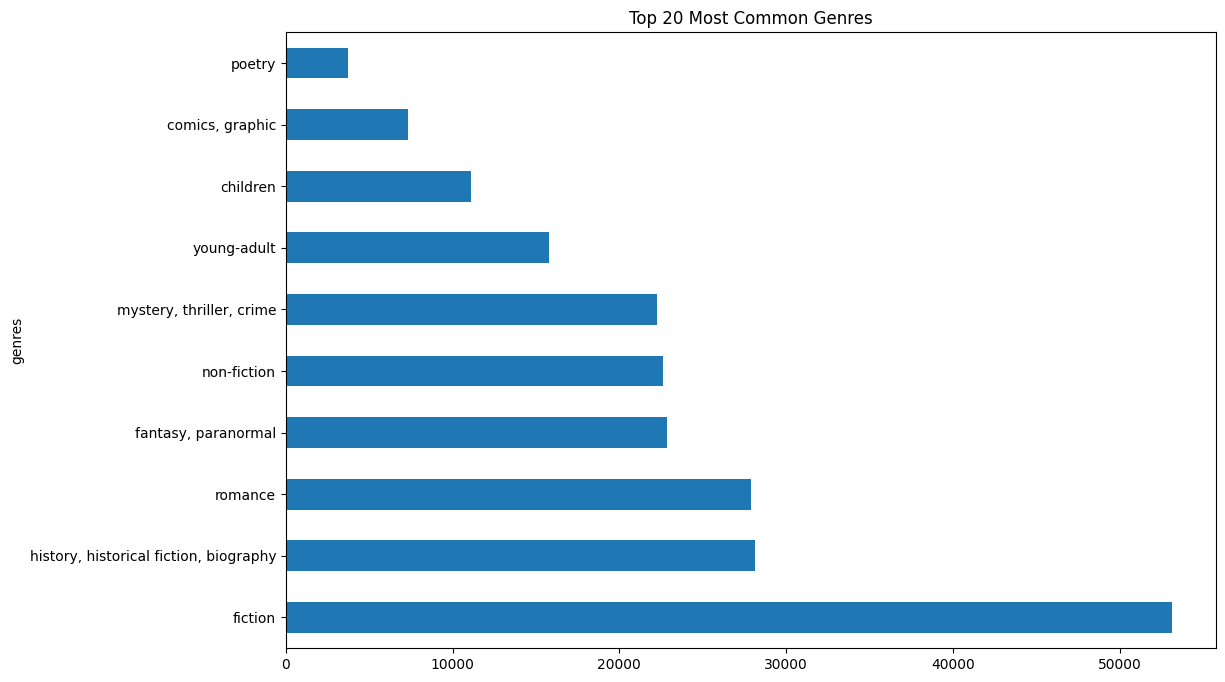

In [ ]:
# Plot the distribution of genres
plt.figure(figsize=(12, 8))
unique_genres.plot(kind="barh")
plt.title("Top 20 Most Common Genres")

In [ ]:
# One-hot encode the genres - we explode the list and then pivot to get a binary matrix of book_id vs genre
book_genres_df.explode("genres").pivot_table(index = "book_id", columns = "genres", aggfunc = "size", fill_value = 0)

genres,children,"comics, graphic","fantasy, paranormal",fiction,"history, historical fiction, biography","mystery, thriller, crime",non-fiction,poetry,romance,young-adult
book_id,,,,,,,,,,
224,0,0,0,1,0,1,0,0,0,0
228,0,0,0,1,0,1,1,0,0,0
229,0,0,0,1,1,1,0,0,0,0
420,0,0,0,1,1,0,1,0,0,0
421,0,0,0,1,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...
36465694,1,0,0,0,0,0,0,0,0,0
36466035,1,1,1,1,0,0,0,0,1,1
36466848,0,1,0,0,0,0,0,0,0,0


## EDA Findings
- min-max normalise for num_pages (convert to str first)
- turn is_ebook into actual boolean
- cleaned data to db
- drop ratings = 0 rows entirely in interaction_df as not useful for training  (aka is_read = true)
- Filter books to english only
- average rating to int
- join book_genre onto book_df and save book genres as json
- bookid to bookname mapping

# Columns to Keep post transformations
My Books -> BookID, MyRating, AverageRating
Books -> BookID, num_pages, is_ebook, average_ratings, descriptions, title, ratings_count
Interactions -> user_id, book_id, rating
Genres -> All